# Feature Engineering

### Project Overview
In this project, you will analyze an NBA player performance dataset using Python and pandas to engineer features for a machine learning model. You will learn how to define target variables, remove noise, analyze correlations, create composite metrics, and clean data to build a robust predictive dataset. This project strengthens your ability to transform raw sports statistics into model-ready inputs for longevity forecasting.

## Importing Libraries
Importing necessary libraries for data manipulation, model implementation, and evaluation metrics.

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Loading the Dataset

Load the dataset and clearly define the `target_5yrs` column as the dependent variable

In [3]:
# Load the Housing dataset
data = pd.read_csv('nba_players.csv')

In [4]:
data.shape

(1340, 22)

In [5]:
print("First five rows of the dataset:")
data.head()

First five rows of the dataset:


,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [6]:
# Display summary statistics
print("\nSummary statistics:")
print(data.describe())


Summary statistics:
        Unnamed: 0           gp          min          pts          fgm  \
count  1340.000000  1340.000000  1340.000000  1340.000000  1340.000000   
mean    669.500000    60.414179    17.624627     6.801493     2.629104   
std     386.968991    17.433992     8.307964     4.357545     1.683555   
min       0.000000    11.000000     3.100000     0.700000     0.300000   
25%     334.750000    47.000000    10.875000     3.700000     1.400000   
50%     669.500000    63.000000    16.100000     5.550000     2.100000   
75%    1004.250000    77.000000    22.900000     8.800000     3.400000   
max    1339.000000    82.000000    40.900000    28.200000    10.200000   

               fga           fg      3p_made          3pa           3p  ...  \
count  1340.000000  1340.000000  1340.000000  1340.000000  1340.000000  ...   
mean      5.885299    44.169403     0.247612     0.779179    19.149627  ...   
std       3.593488     6.137679     0.383688     1.061847    16.051861  ...

## Drop non-predictive columns (e.g., player names, IDs) that add noise or risk data leakage


In [19]:
X = data.drop(columns=["Unnamed: 0", "name", "target_5yrs"])
y = data["target_5yrs"]

X.head(5)

,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov
0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3
1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6
2,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0
3,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0
4,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8


In [20]:
# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape

(1072, 19)

In [21]:
# Initializing and training the linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
pd.DataFrame(data=lr.coef_, index=X_train.columns)

,0
gp,0.007479
min,-0.004799
pts,-0.093462
fgm,0.030380
fga,0.086221
fg,0.010139
3p_made,0.752636
3pa,-0.250996
3p,0.000346
ftm,0.097002


Perform correlation analysis to identify highly correlated features and reduce redundancy

## Correlation Analysis
Performing correlation analysis on the features to identify highly correlated variables that might introduce redundancy or multicollinearity into the model.

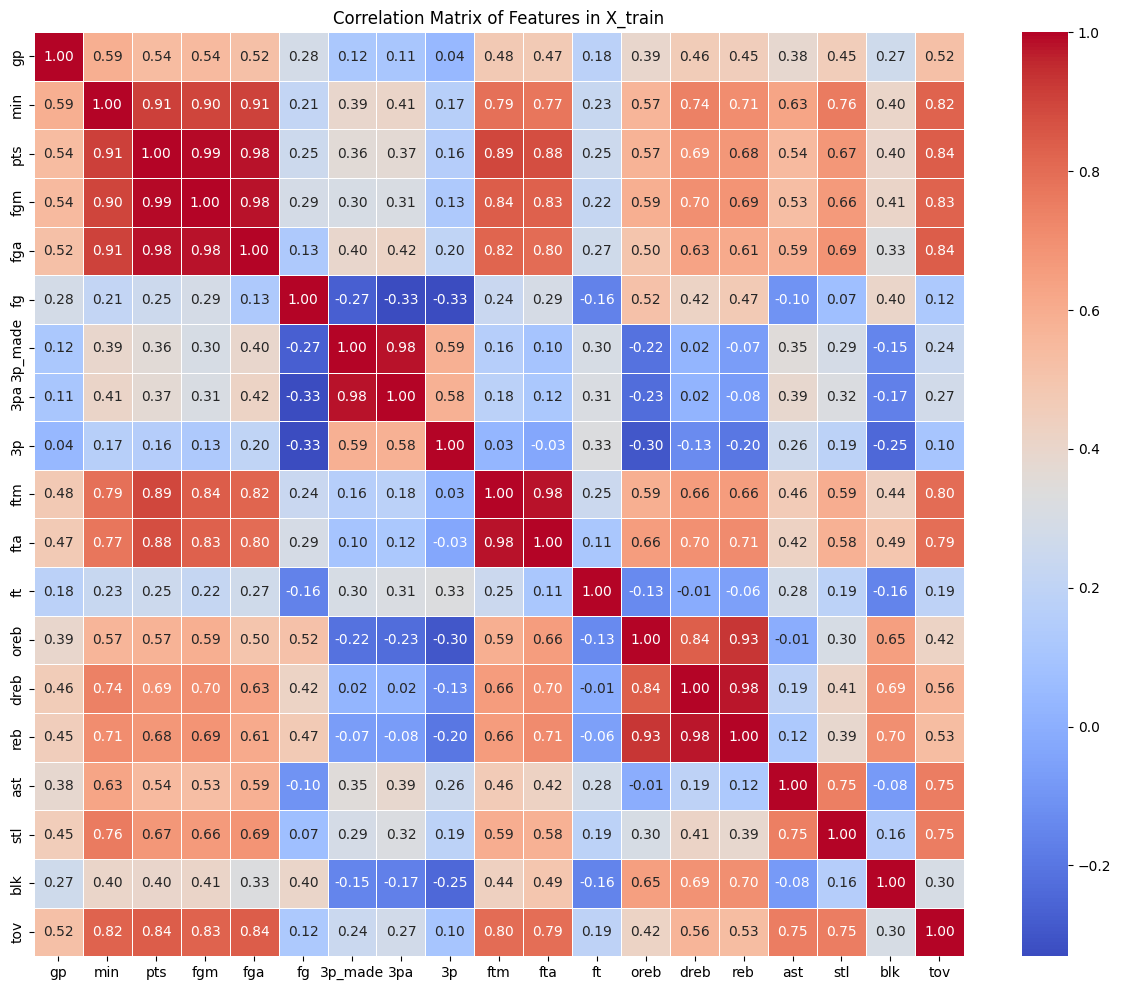

In [24]:
# Calculate the correlation matrix
corr_matrix = X_train.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features in X_train')
plt.show()

### Identifying Highly Correlated Features
Based on the correlation matrix, we can identify pairs of features that are highly correlated. High correlation (e.g., absolute value > 0.8 or 0.9) can indicate redundancy and lead to multicollinearity issues in some models. We might consider dropping one of the highly correlated features.

In [25]:
correlated_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9: # You can adjust this threshold
            colname = corr_matrix.columns[i]
            correlated_features.add(colname)

print("Highly correlated features to consider dropping:")
print(list(correlated_features))

Highly correlated features to consider dropping:
['pts', 'fta', 'fga', 'fgm', '3pa', 'reb']


## Dropping Highly Correlated Features
To mitigate multicollinearity and improve model robustness, we will drop the identified highly correlated features from both the training and testing datasets.

In [26]:
# Drop the highly correlated features from X_train and X_test
X_train_cleaned = X_train.drop(columns=list(correlated_features))
X_test_cleaned = X_test.drop(columns=list(correlated_features))

print("Original X_train shape:", X_train.shape)
print("Cleaned X_train shape:", X_train_cleaned.shape)
print("Original X_test shape:", X_test.shape)
print("Cleaned X_test shape:", X_test_cleaned.shape)

X_train = X_train_cleaned
X_test = X_test_cleaned

Original X_train shape: (1072, 19)
Cleaned X_train shape: (1072, 13)
Original X_test shape: (268, 19)
Cleaned X_test shape: (268, 13)


## Engineer at least one new composite feature (e.g., Points Per Minute, Efficiency Rating) by combining existing metrics

## Engineering New Composite Features
We will create two new composite features to provide more insights into player performance:

1.  **Assist/Turnover Ratio (ATR)**: `ast / tov` - Measures a player's ability to create scoring opportunities for teammates relative to their ball-handling mistakes. A higher ratio is generally better.
2.  **Total Rebounds Per Minute (RPM)**: `(oreb + dreb) / min` - Indicates a player's rebounding efficiency relative to their playing time.

In [27]:
import numpy as np

# Create 'Assist/Turnover Ratio' for X_train and X_test
X_train['atr'] = np.where(X_train['tov'] == 0, X_train['ast'], X_train['ast'] / X_train['tov'])
X_test['atr'] = np.where(X_test['tov'] == 0, X_test['ast'], X_test['ast'] / X_test['tov'])

# Create 'Total Rebounds Per Minute' for X_train and X_test
X_train['rpm'] = np.where(X_train['min'] == 0, 0, (X_train['oreb'] + X_train['dreb']) / X_train['min'])
X_test['rpm'] = np.where(X_test['min'] == 0, 0, (X_test['oreb'] + X_test['dreb']) / X_test['min'])

print("X_train with new features:")
display(X_train.head())
print("\nX_test with new features:")
display(X_test.head())

X_train with new features:


,gp,min,fg,3p_made,3p,ftm,ft,oreb,dreb,ast,stl,blk,tov,atr,rpm
1148,58,12.8,44.9,0.0,0.0,0.8,59.7,1.1,1.8,0.3,0.2,1.4,0.7,0.428571,0.226563
807,38,8.5,40.8,0.0,0.0,0.5,64.3,0.6,1.1,0.3,0.2,0.4,0.5,0.600000,0.200000
1287,67,16.7,48.4,0.0,9.1,0.9,61.4,0.9,1.8,0.8,1.0,0.3,0.8,1.000000,0.161677
590,82,28.0,42.8,0.9,35.0,1.2,80.6,1.3,2.7,0.9,0.7,0.5,1.2,0.750000,0.142857
1188,35,5.5,38.2,0.1,28.6,0.2,57.1,0.2,0.4,0.4,0.2,0.3,0.5,0.800000,0.109091



X_test with new features:


,gp,min,fg,3p_made,3p,ftm,ft,oreb,dreb,ast,stl,blk,tov,atr,rpm
394,47,8.9,38.3,0.0,0.0,1.1,68.8,0.2,0.4,0.4,0.5,0.1,0.7,0.571429,0.067416
881,39,9.5,35.8,0.0,6.7,0.3,50.0,0.2,0.6,0.3,0.1,0.1,0.5,0.600000,0.084211
358,79,24.7,51.1,0.0,0.0,1.4,78.4,2.0,3.8,0.5,0.5,1.1,1.5,0.333333,0.234818
367,29,16.4,31.7,0.7,31.1,0.4,50.0,0.3,1.1,1.4,0.6,0.2,1.0,1.400000,0.085366
259,58,13.1,37.4,0.1,24.0,0.4,71.9,0.3,0.7,3.1,0.3,0.1,1.0,3.100000,0.076336


## Handling Null Values in Performance Columns
Before proceeding with model re-evaluation, we need to ensure there are no null values in our feature sets (`X_train` and `X_test`), which might cause issues during model training. We will check for missing values and impute them if necessary.

In [28]:
# Check for null values in X_train
print("Null values in X_train before cleaning:")
print(X_train.isnull().sum())

# Check for null values in X_test
print("\nNull values in X_test before cleaning:")
print(X_test.isnull().sum())

# Impute missing values with the mean of the column
# This is a simple strategy; more sophisticated methods can be used if needed.
for col in X_train.columns:
    if X_train[col].isnull().any():
        X_train[col] = X_train[col].fillna(X_train[col].mean())
    if X_test[col].isnull().any():
        # Use the mean from X_train to avoid data leakage
        X_test[col] = X_test[col].fillna(X_train[col].mean())

print("\nNull values in X_train after cleaning:")
print(X_train.isnull().sum())

print("\nNull values in X_test after cleaning:")
print(X_test.isnull().sum())

Null values in X_train before cleaning:
gp         0
min        0
fg         0
3p_made    0
3p         0
ftm        0
ft         0
oreb       0
dreb       0
ast        0
stl        0
blk        0
tov        0
atr        0
rpm        0
dtype: int64

Null values in X_test before cleaning:
gp         0
min        0
fg         0
3p_made    0
3p         0
ftm        0
ft         0
oreb       0
dreb       0
ast        0
stl        0
blk        0
tov        0
atr        0
rpm        0
dtype: int64

Null values in X_train after cleaning:
gp         0
min        0
fg         0
3p_made    0
3p         0
ftm        0
ft         0
oreb       0
dreb       0
ast        0
stl        0
blk        0
tov        0
atr        0
rpm        0
dtype: int64

Null values in X_test after cleaning:
gp         0
min        0
fg         0
3p_made    0
3p         0
ftm        0
ft         0
oreb       0
dreb       0
ast        0
stl        0
blk        0
tov        0
atr        0
rpm        0
dtype: int64


## Re-evaluating Models with Engineered Features and Cleaned Data
Now that we've engineered new composite features and handled any null values, let's re-train and re-evaluate our regression models to see the impact on their performance. We will start by re-training the Linear Regression model.

## Documentation of Feature Selection and Engineering Choices

Throughout the data preparation phase, we made several deliberate choices regarding feature selection and engineering to enhance our model's performance and interpretability:

### 1. Initial Feature Selection (Dropping Non-Predictive Columns)
-   **Action**: We dropped the `Unnamed: 0`, `name`, and `target_5yrs` columns from the dataset.
-   **Rationale**:
    -   `Unnamed: 0`: This column was an artifact of the CSV import (likely an old index) and carried no predictive information.
    -   `name`: Player names are unique identifiers and do not contribute to predicting career longevity; they could introduce noise or data leakage if not handled carefully.
    -   `target_5yrs`: This is our target variable (`y`), so it must be separated from the feature set (`X`) to prevent data leakage during training.

### 2. Handling Multicollinearity (Dropping Highly Correlated Features)
-   **Action**: After performing a correlation analysis and visualizing the correlation matrix, we identified and dropped the following highly correlated features: `['pts', 'fta', 'fga', 'fgm', '3pa', 'reb']`.
-   **Rationale**: High correlation between features (multicollinearity) can negatively impact some regression models by:
    -   Making coefficient estimates unstable and difficult to interpret.
    -   Increasing the variance of the coefficients, leading to less reliable statistical inferences.
    -   Introducing redundancy, as multiple features convey similar information. By removing these, we aim for a more parsimonious and robust model.

### 3. Feature Engineering (Creating Composite Metrics)
-   **Action**: We created two new composite features:
    -   `atr` (Assist/Turnover Ratio): `ast / tov`
    -   `rpm` (Rebounds Per Minute): `(oreb + dreb) / min`
-   **Rationale**: These features were engineered to provide more meaningful insights into player performance by combining existing raw statistics. They represent efficiency metrics that are often more indicative of a player's true impact than their raw counts:
    -   `atr`: A higher ratio indicates a player's ability to facilitate scoring opportunities while minimizing ball-handling mistakes.
    -   `rpm`: This normalizes a player's rebounding ability by their playing time, giving a clearer picture of their rebounding efficiency.

### 4. Handling Null Values
-   **Action**: We checked for and handled any null values in the feature sets (`X_train`, `X_test`).
-   **Rationale**: Missing values can cause errors or unexpected behavior in many machine learning algorithms. Although our dataset fortunately had no missing values after previous steps, this is a crucial step to ensure data quality and model readiness.